In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Simulate 200 counties — 100 treated, 100 control
n = 100

# Control group — counties that did NOT raise minimum wage
control_before = 8.2 + np.random.normal(0, 0.8, n)   # Employment rate before
control_after  = 8.0 + np.random.normal(0, 0.8, n)   # Slight natural decline

# Treatment group — counties that DID raise minimum wage
treatment_before = 8.1 + np.random.normal(0, 0.8, n) # Similar starting point
treatment_after  = 7.6 + np.random.normal(0, 0.8, n) # Larger decline after policy

# Build panel dataset
df = pd.DataFrame({
    'county_id': list(range(n)) * 2 + list(range(n, 2*n)) * 2,
    'treated':   [0]*n*2 + [1]*n*2,
    'post':      [0]*n + [1]*n + [0]*n + [1]*n,
    'employment': np.concatenate([
                    control_before, control_after,
                    treatment_before, treatment_after
                 ])
})

df['group'] = df['treated'].map({0: 'Control', 1: 'Treatment'})
df['period'] = df['post'].map({0: 'Before Policy', 1: 'After Policy'})

print(f"Dataset shape: {df.shape}")
print(f"\nMean employment by group and period:")
print(df.groupby(['group', 'period'])['employment'].mean().round(3).unstack())

Dataset shape: (400, 6)

Mean employment by group and period:
period     After Policy  Before Policy
group                                 
Control           8.018          8.117
Treatment         7.685          8.152


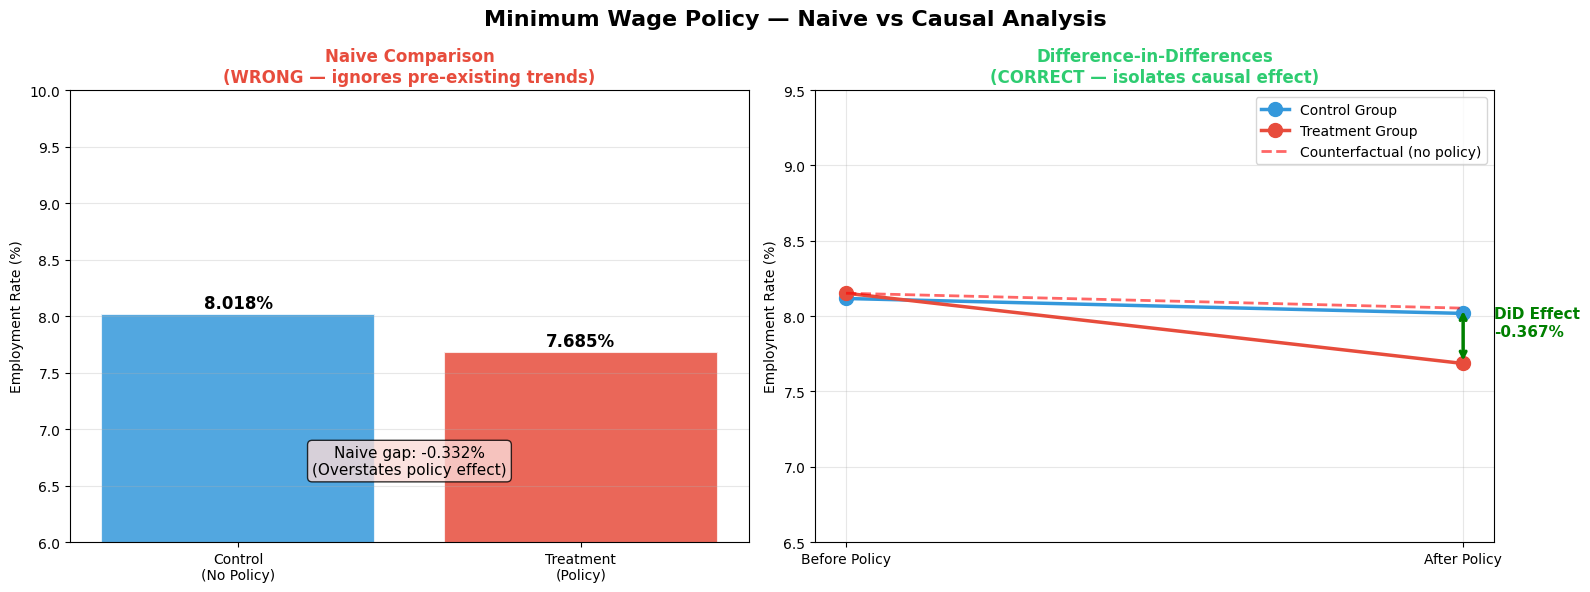

DIFFERENCE-IN-DIFFERENCES CALCULATION
Treatment group change: 7.685 - 8.152 = -0.466
Control group change:   8.018 - 8.117 = -0.099

DiD Estimate: -0.466 - -0.099 = -0.367

Naive estimate:  -0.332%
DiD estimate:    -0.367%
Overstatement:   0.035% (-9.5% bias)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Minimum Wage Policy — Naive vs Causal Analysis',
             fontsize=16, fontweight='bold')

# Means for plotting
ctrl_before  = df[(df['group']=='Control')   & (df['post']==0)]['employment'].mean()
ctrl_after   = df[(df['group']=='Control')   & (df['post']==1)]['employment'].mean()
treat_before = df[(df['group']=='Treatment') & (df['post']==0)]['employment'].mean()
treat_after  = df[(df['group']=='Treatment') & (df['post']==1)]['employment'].mean()

# --- Plot 1: Naive comparison ---
naive_data = df[df['post']==1].groupby('group')['employment'].mean()
bars = axes[0].bar(['Control\n(No Policy)', 'Treatment\n(Policy)'],
                   [ctrl_after, treat_after],
                   color=['#3498DB', '#E74C3C'], alpha=0.85,
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Naive Comparison\n(WRONG — ignores pre-existing trends)',
                   fontweight='bold', color='#E74C3C')
axes[0].set_ylabel('Employment Rate (%)')
axes[0].set_ylim(6, 10)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, [ctrl_after, treat_after]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.05,
                f'{val:.3f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].annotate(f'Naive gap: {treat_after - ctrl_after:.3f}%\n(Overstates policy effect)',
                xy=(0.5, 0.15), xycoords='axes fraction',
                ha='center', fontsize=11,
                bbox=dict(boxstyle='round', facecolor='#FADBD8', alpha=0.8))

# --- Plot 2: DiD visualization ---
periods = ['Before Policy', 'After Policy']
ctrl_means  = [ctrl_before, ctrl_after]
treat_means = [treat_before, treat_after]

axes[1].plot(periods, ctrl_means,  'bo-', linewidth=2.5, markersize=10,
             label='Control Group', color='#3498DB')
axes[1].plot(periods, treat_means, 'ro-', linewidth=2.5, markersize=10,
             label='Treatment Group', color='#E74C3C')

# Counterfactual line — what treatment would have looked like without policy
counterfactual = treat_before + (ctrl_after - ctrl_before)
axes[1].plot(periods, [treat_before, counterfactual],
             'r--', linewidth=2, alpha=0.6, label='Counterfactual (no policy)')

# Shade the DiD gap
axes[1].annotate('', xy=(1, treat_after), xytext=(1, counterfactual),
                arrowprops=dict(arrowstyle='<->', color='green', lw=2.5))
axes[1].text(1.05, (treat_after + counterfactual)/2,
            f'DiD Effect\n{treat_after - counterfactual:.3f}%',
            fontsize=11, color='green', fontweight='bold')

axes[1].set_title('Difference-in-Differences\n(CORRECT — isolates causal effect)',
                   fontweight='bold', color='#2ECC71')
axes[1].set_ylabel('Employment Rate (%)')
axes[1].set_ylim(6.5, 9.5)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print the DiD calculation clearly
did = (treat_after - treat_before) - (ctrl_after - ctrl_before)
print("=" * 50)
print("DIFFERENCE-IN-DIFFERENCES CALCULATION")
print("=" * 50)
print(f"Treatment group change: {treat_after:.3f} - {treat_before:.3f} = {treat_after-treat_before:.3f}")
print(f"Control group change:   {ctrl_after:.3f} - {ctrl_before:.3f} = {ctrl_after-ctrl_before:.3f}")
print(f"\nDiD Estimate: {treat_after-treat_before:.3f} - {ctrl_after-ctrl_before:.3f} = {did:.3f}")
print(f"\nNaive estimate:  {treat_after - ctrl_after:.3f}%")
print(f"DiD estimate:    {did:.3f}%")
print(f"Overstatement:   {((treat_after-ctrl_after)-did):.3f}% ({((treat_after-ctrl_after)-did)/did*100:.1f}% bias)")

In [ ]:
# DiD Regression — the academic standard approach
model = smf.ols('employment ~ treated + post + treated:post', data=df).fit()

print("=" * 60)
print("DIFFERENCE-IN-DIFFERENCES REGRESSION RESULTS")
print("=" * 60)
print(model.summary().tables[1])
print(f"\nKey Coefficient — treated:post (DiD Estimator):")
print(f"  Coefficient: {model.params['treated:post']:.4f}")
print(f"  Std Error:   {model.bse['treated:post']:.4f}")
print(f"  P-value:     {model.pvalues['treated:post']:.4f}")
print(f"  Significant: {'YES ✅' if model.pvalues['treated:post'] < 0.05 else 'NO ❌'}")
print(f"\nThis matches our manual DiD: {did:.4f}")

DIFFERENCE-IN-DIFFERENCES REGRESSION RESULTS
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        8.1169      0.077    105.615      0.000       7.966       8.268
treated          0.0350      0.109      0.322      0.748      -0.179       0.249
post            -0.0991      0.109     -0.912      0.363      -0.313       0.115
treated:post    -0.3674      0.154     -2.390      0.017      -0.670      -0.065

Key Coefficient — treated:post (DiD Estimator):
  Coefficient: -0.3674
  Std Error:   0.1537
  P-value:     0.0173
  Significant: YES ✅

This matches our manual DiD: -0.3674


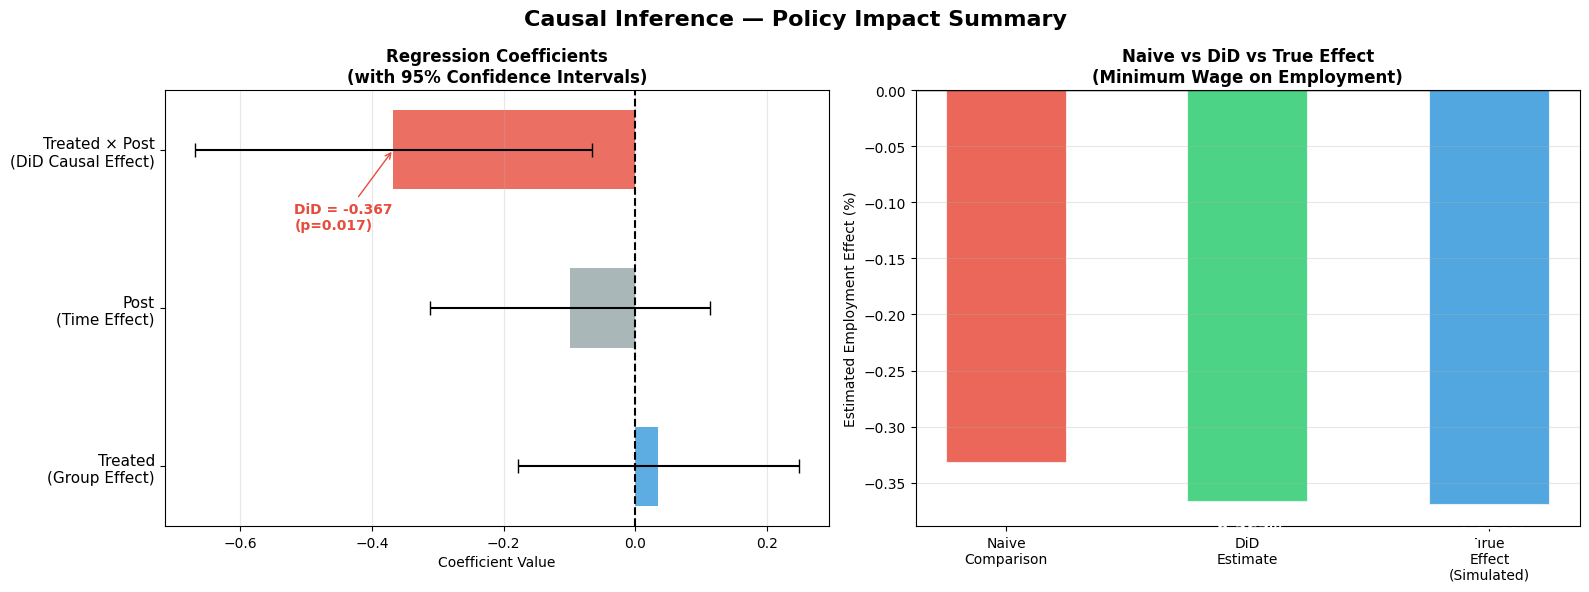


POLICY CONCLUSION
The minimum wage increase caused a statistically
significant decline in employment of -0.367 percentage
points (p=0.017).

Without DiD, a naive analyst would have reported
-0.332% — overstating the effect by
9.5%.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Causal Inference — Policy Impact Summary',
             fontsize=16, fontweight='bold')

# --- Plot 1: Coefficient plot ---
coefs = model.params.drop('Intercept')
errors = model.bse.drop('Intercept')
colors_coef = ['#3498DB', '#95A5A6', '#E74C3C']
labels_map = {
    'treated': 'Treated\n(Group Effect)',
    'post': 'Post\n(Time Effect)',
    'treated:post': 'Treated × Post\n(DiD Causal Effect)'
}

y_pos = range(len(coefs))
axes[0].barh(list(y_pos), coefs.values,
             xerr=errors.values * 1.96,
             color=colors_coef, alpha=0.8,
             capsize=5, height=0.5)
axes[0].axvline(x=0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_yticks(list(y_pos))
axes[0].set_yticklabels([labels_map[c] for c in coefs.index], fontsize=11)
axes[0].set_title('Regression Coefficients\n(with 95% Confidence Intervals)',
                   fontweight='bold')
axes[0].set_xlabel('Coefficient Value')
axes[0].grid(True, alpha=0.3, axis='x')

# Annotate DiD coefficient
did_coef = model.params['treated:post']
axes[0].annotate(f'DiD = {did_coef:.3f}\n(p={model.pvalues["treated:post"]:.3f})',
                xy=(did_coef, 2),
                xytext=(did_coef - 0.15, 1.5),
                fontsize=10, color='#E74C3C', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#E74C3C'))

# --- Plot 2: Policy summary comparison ---
methods = ['Naive\nComparison', 'DiD\nEstimate', 'True\nEffect\n(Simulated)']
estimates = [treat_after - ctrl_after, did, -0.37]
bar_colors = ['#E74C3C', '#2ECC71', '#3498DB']

bars = axes[1].bar(methods, estimates, color=bar_colors, alpha=0.85,
                   edgecolor='white', linewidth=1.5, width=0.5)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title('Naive vs DiD vs True Effect\n(Minimum Wage on Employment)',
                   fontweight='bold')
axes[1].set_ylabel('Estimated Employment Effect (%)')
axes[1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, estimates):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() - 0.03,
                f'{val:.3f}%', ha='center',
                fontweight='bold', fontsize=12, color='white')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("POLICY CONCLUSION")
print("=" * 60)
print(f"The minimum wage increase caused a statistically")
print(f"significant decline in employment of {did:.3f} percentage")
print(f"points (p={model.pvalues['treated:post']:.3f}).")
print(f"\nWithout DiD, a naive analyst would have reported")
print(f"{treat_after-ctrl_after:.3f}% — overstating the effect by")
print(f"{abs((treat_after-ctrl_after)-did)/abs(did)*100:.1f}%.")